# TP4: Classification Robuste - Partie 2

## Phase II: Classification Basée sur les Frontières et Non-Linéaire

Cette partie continue le TP4 avec les arbres de décision, le boosting et les SVM.

<div style="
    font-family: 'Segoe UI', system-ui, sans-serif;
    max-width: 900px;
    margin: 40px auto;
    padding: 0 20px;
    color: #333;
">

<!-- Titre principal avec animation néon violet -->
<h1 style="
        display: inline-block;
        background: linear-gradient(90deg,
            #ffffff,
            #b0b0b0,
            #8e24aa,
            #7b1fa2);
        background-size: 300% 100%;
        -webkit-background-clip: text;
        background-clip: text;
        color: transparent;
        font-size: 2.8rem;
        font-weight: 900;
        font-family: 'Montserrat', sans-serif;
        animation: neonFlow 3s ease-in-out infinite,
                   neonFlicker 2s ease-in-out infinite;
        text-shadow: 0 0 8px rgba(142, 36, 170, 0.4);
        padding: 15px 0;
        margin: 0 0 20px 0;
        letter-spacing: 1px;
        border-bottom: 3px solid;
        border-image: linear-gradient(90deg, #f0f0f0, #8e24aa, #f0f0f0) 1;
    ">
     TP4: Classification Robuste - Partie 2
    </h1>

<style>
.title {
    /* Dégradé : Blanc vers Gris vers Bleu */
    background: linear-gradient(to right, 
        #FFFFFF, /* Blanc */
        #B0B0B0, /* Gris clair/moyen */
        #9400abff  /* Bleu Cobalt (ajustable selon vos préférences) */
    );
    
    font-family: 'Arial', sans-serif;
    font-size: 2.2em;
    font-weight: 800;
    
    /* Effet de clipping pour appliquer la couleur au texte */
    -webkit-background-clip: text;
    background-clip: text;
    color: transparent;
    
    display: inline-block;
}
</style>

<h2 class="title">

 Phase II: Classification Basée sur les Frontières et  Frontière Non-Linéaire
</h2>
<h3>Cette partie continue le TP4 avec les arbres de décision, le boosting et les SVM.</h3>

In [1]:
# Imports nécessaires (à exécuter si ce notebook est ouvert indépendamment)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score,
    precision_recall_curve, average_precision_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Rechargement des données
data = load_breast_cancer()
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Données rechargées et préparées!")

✅ Données rechargées et préparées!


<style>
    .medical-section { font-family: 'Segoe UI', sans-serif; line-height: 1.6; }
    .gradient-text {
        background: linear-gradient(to right, #ffffff, #4facfe, #0006abff);
        -webkit-background-clip: text; background-clip: text;
        color: transparent; display: inline-block; font-weight: 800; margin-bottom: 10px;
    }
    .importance-high { font-size: 2.2em; }
    .importance-medium { font-size: 1.5em; margin-top: 20px; }
    .importance-low { font-size: 1.1em; color: #ffffff; }
    .medical-list { list-style-type: none; padding-left: 5px; }
    .medical-list li { margin-bottom: 8px; padding-left: 15px; border-left: 3px solid #0006abff; }
</style>

<div class="medical-section">
    <h1 class="gradient-text importance-high"> Tache 2.1: Arbres de Décision et Boosting</h1>
    <h2 class="gradient-text importance-medium">📚 Théorie des Arbres de Décision</h2>
    <p class="importance-low">
        <strong>Principe:</strong> Structure hiérarchique de décisions basées sur les features. 
        L'algorithme <strong>CART</strong> utilise l'Impureté de Gini comme critère de division :
    </p>
</div>

$$\boxed{G = 1 - \sum_{i=1}^{C} p_i^2}$$

<div class="medical-section">
    <p class="importance-low">
        Ou le critère d'<strong>Entropie</strong> pour mesurer le désordre dans les données :
    </p>
</div>

$$\boxed{H = -\sum_{i=1}^{C} p_i \log_2(p_i)}$$

<div class="medical-section">
    <h2 class="gradient-text importance-medium">⚙️ Analyse et Performance</h2>
    <ul class="medical-list importance-low">
        <li><strong>Complexité de construction :</strong></li>
    </ul>
</div>

$$\boxed{O(n \cdot m \cdot \log(n) \cdot \text{depth})}$$

 Construction: $O(n \cdot m \cdot \log(n) \cdot depth)$

  - $n$ = nombre d'échantillons

  - $m$ = nombre de features

  - $depth$ = profondeur de l'arbre

<div class="medical-section">
    <ul class="medical-list importance-low">
        <li> <h3><strong>Avantages :</strong> </h3> <li>Interprétable</li> <li>non-linéaire</li> <li>importance des features.</li> </li>
        <li> <h3> <strong>Inconvénients :</strong> </h3> <li>Tendance au surapprentissage (Overfitting)</li> <li>instable.</li></li>
    </ul>
</div>

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

print("="*60)
print("🚀 ENTRAÎNEMENT: Arbre de Décision")
print("="*60)

# Entraînement de l'arbre de décision
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Évaluation
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)

print(f"Accuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print(f"\nProfondeur de l'arbre: {dt_model.get_depth()}")
print(f"Nombre de feuilles: {dt_model.get_n_leaves()}")
print("="*60)

🚀 ENTRAÎNEMENT: Arbre de Décision
Accuracy:  0.9211
Precision: 0.9437
Recall:    0.9306
F1-Score:  0.9371

Profondeur de l'arbre: 5
Nombre de feuilles: 12



📊 TOP 10 Features les Plus Importantes:
worst radius                   : 0.7465
worst concave points           : 0.1242
texture error                  : 0.0466
worst texture                  : 0.0391
worst concavity                : 0.0175
worst smoothness               : 0.0105
worst area                     : 0.0082
area error                     : 0.0075
mean radius                    : 0.0000
concavity error                : 0.0000


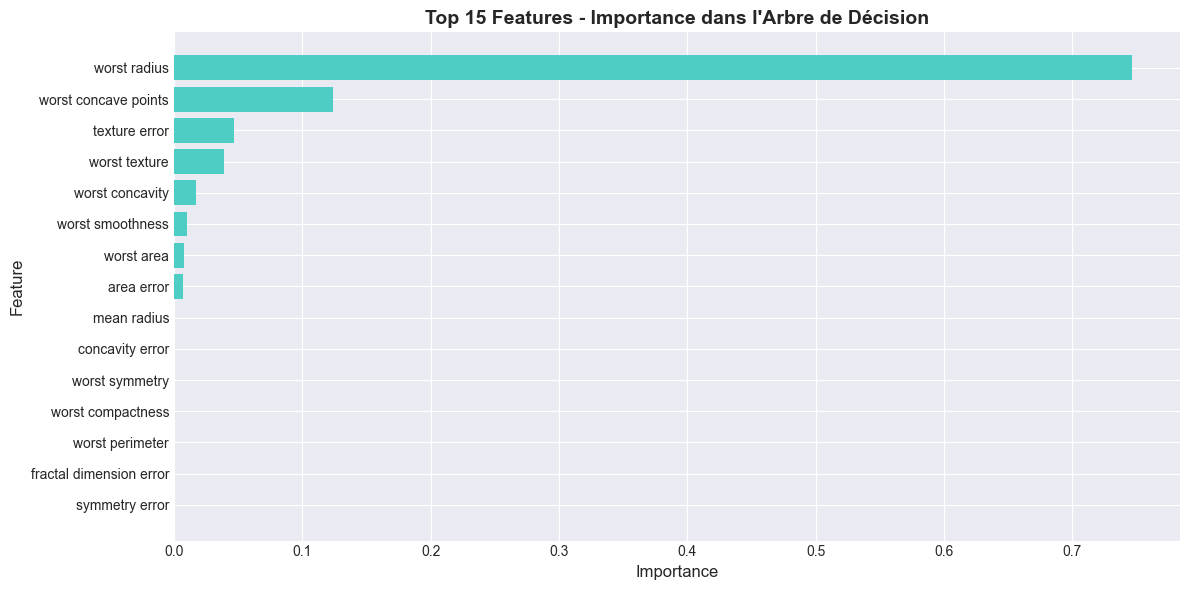

In [ ]:
# Analyse de l'importance des features
feature_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 TOP 10 Features les Plus Importantes:")
print("="*60)
for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']:30s} : {row['importance']:.4f}")
print("="*60)

# Visualisation de l'importance des features
plt.figure(figsize=(12, 6))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'], color='#4ECDC4')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Features - Importance dans l\'Arbre de Décision', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

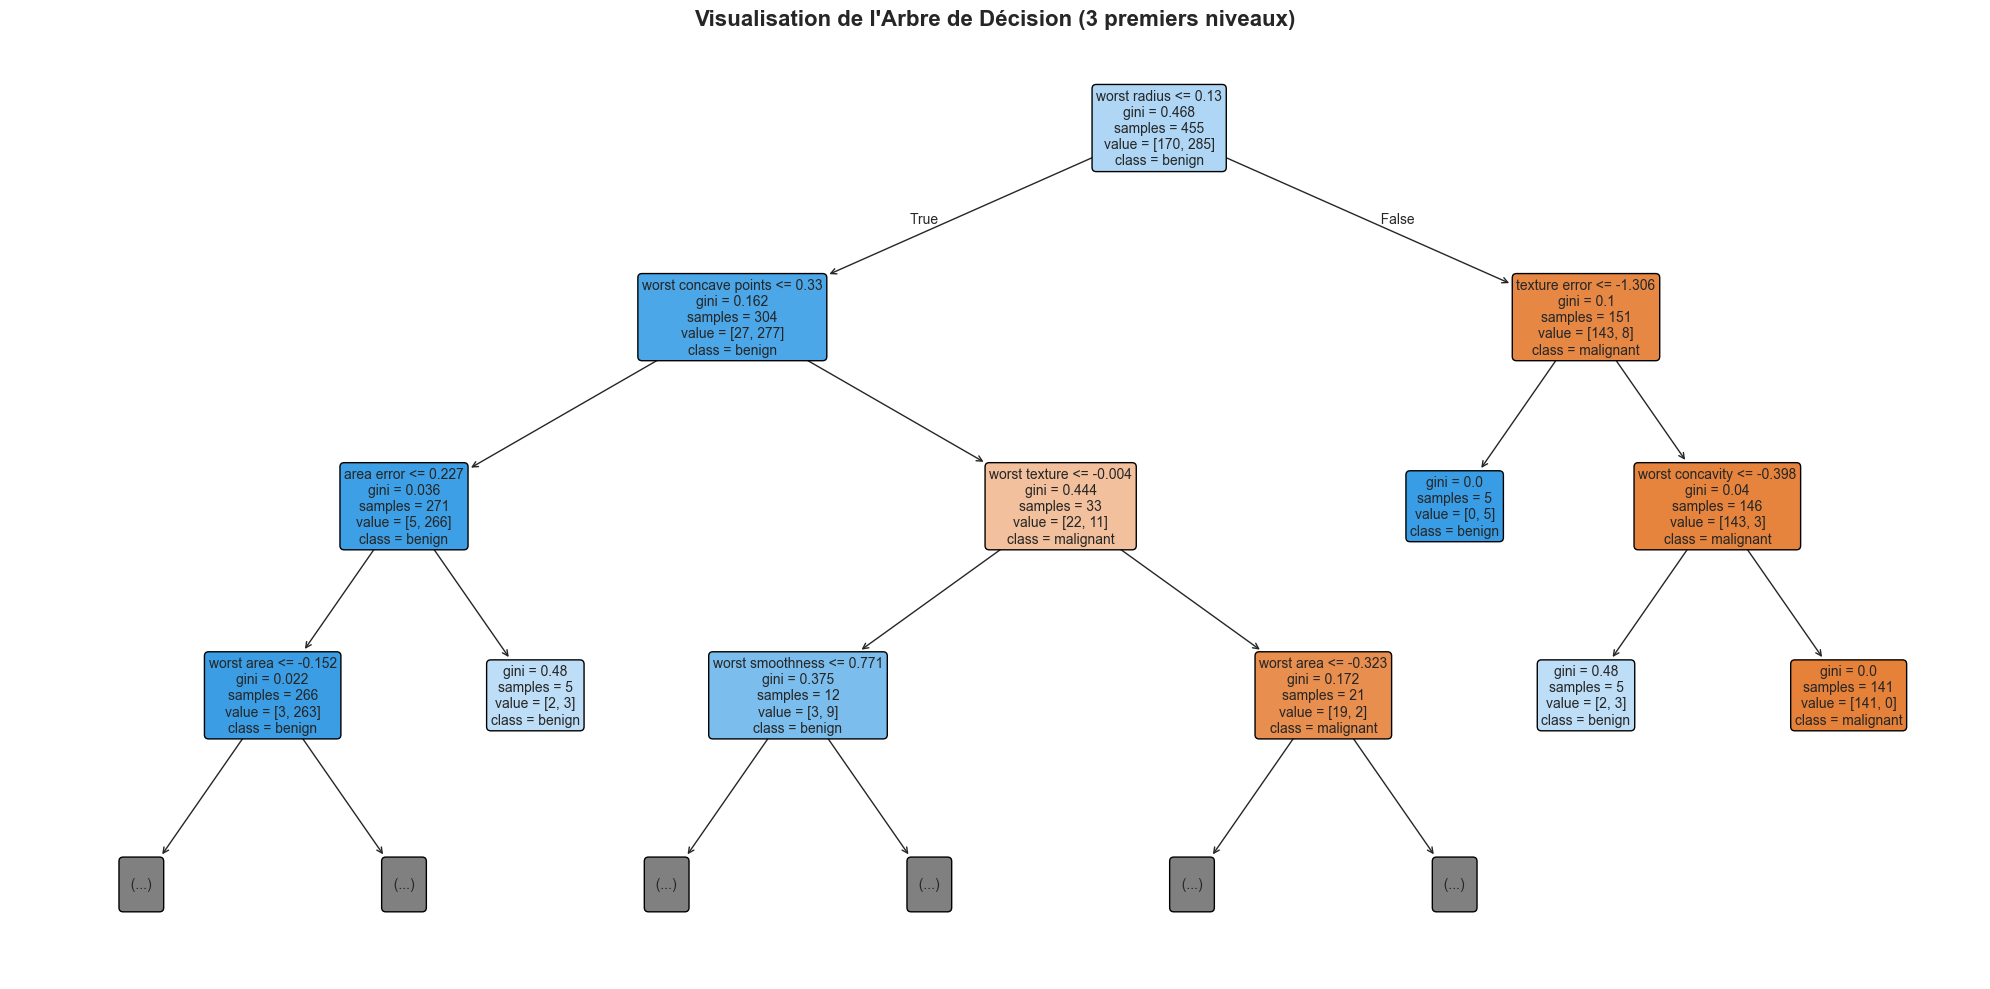


💡 Explication de l'algorithme CART:
   1. Sélectionner la meilleure feature et le meilleur seuil pour diviser les données
   2. Critère: Minimiser l'impureté de Gini ou l'entropie
   3. Répéter récursivement jusqu'à atteindre les critères d'arrêt
   4. Complexité: O(n * m * log(n) * depth) = O(455 * 30 * log(455) * 5)


In [ ]:
# Visualisation de l'arbre (simplifié)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, 
          max_depth=3,  # Limiter la profondeur pour la lisibilité
          feature_names=data.feature_names,
          class_names=data.target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Visualisation de l\'Arbre de Décision (3 premiers niveaux)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Explication de l'algorithme CART:")
print("   1. Sélectionner la meilleure feature et le meilleur seuil pour diviser les données")
print("   2. Critère: Minimiser l'impureté de Gini ou l'entropie")
print("   3. Répéter récursivement jusqu'à atteindre les critères d'arrêt")
print(f"   4. Complexité: O(n * m * log(n) * depth) = O({X_train.shape[0]} * {X_train.shape[1]} * log({X_train.shape[0]}) * {dt_model.get_depth()})")

<style>
    /* Conteneur principal */
    .medical-section {
        font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
        line-height: 1.6;
    }

    /* Style pour le titre en dégradé */
    .gradient-text {
        background: linear-gradient(to right, 
            #ffffff,    /* Blanc */
            #4facfe,    /* Bleu clair */
            #0006abff   /* Bleu Cobalt */
        );
        -webkit-background-clip: text;
        background-clip: text;
        color: transparent;
        display: inline-block;
        font-weight: 800;
        margin-bottom: 15px;
    }

    .importance-high {
        font-size: 2.2em;
    }

    .importance-medium {
        font-size: 1.5em;
        margin-top: 25px;
        color: #ffffff;
        display: block;
    }

    /* Corps de texte en blanc pur */
    .text-body {
        font-size: 1.1em;
        color: #ffffff;
    }

    /* Style de la liste médicale */
    .medical-list {
        list-style-type: none;
        padding-left: 5px;
        margin-top: 10px;
    }

    .medical-list li {
        margin-bottom: 10px;
        padding-left: 15px;
        border-left: 3px solid #0006abff;
        color: #ffffff;
    }

    .highlight {
        color: #4facfe;
        font-weight: 600;
    }
</style>

<div class="medical-section">
    <h1 class="gradient-text importance-high">
        🚀 Amélioration avec le Boosting
    </h1>

<strong class="importance-medium">Principe du Boosting</strong>
    <ul class="medical-list text-body">
        <li>Combine plusieurs modèles faibles pour créer un modèle fort</li>
        <li><span class="highlight">AdaBoost :</span> Ajuste les poids des échantillons mal classés</li>
        <li><span class="highlight">Gradient Boosting :</span> Optimise une fonction de perte en ajoutant séquentiellement des arbres</li>
    </ul>

<strong class="importance-medium">Avantages</strong>
    <ul class="medical-list text-body">
        <li>Réduit le biais et la variance</li>
        <li>Performances généralement excellentes</li>
        <li>Robuste au surapprentissage grâce à la régularisation</li>
    </ul>
</div>

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

print("="*60)
print("🚀 ENTRAÎNEMENT: Boosting Methods")
print("="*60)

# AdaBoost
print("\n1. AdaBoost...")
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
ada_model.fit(X_train_scaled, y_train)
y_pred_ada = ada_model.predict(X_test_scaled)
y_pred_proba_ada = ada_model.predict_proba(X_test_scaled)[:, 1]

accuracy_ada = accuracy_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada)
recall_ada = recall_score(y_test, y_pred_ada)

print(f"   Accuracy:  {accuracy_ada:.4f}")
print(f"   Precision: {precision_ada:.4f}")
print(f"   Recall:    {recall_ada:.4f}")
print(f"   F1-Score:  {f1_ada:.4f}")

# Gradient Boosting
print("\n2. Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
y_pred_gb = gb_model.predict(X_test_scaled)
y_pred_proba_gb = gb_model.predict_proba(X_test_scaled)[:, 1]

accuracy_gb = accuracy_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)

print(f"   Accuracy:  {accuracy_gb:.4f}")
print(f"   Precision: {precision_gb:.4f}")
print(f"   Recall:    {recall_gb:.4f}")
print(f"   F1-Score:  {f1_gb:.4f}")
print("="*60)

🚀 ENTRAÎNEMENT: Boosting Methods

1. AdaBoost...
   Accuracy:  0.9561
   Precision: 0.9467
   Recall:    0.9861
   F1-Score:  0.9660

2. Gradient Boosting...
   Accuracy:  0.9561
   Precision: 0.9467
   Recall:    0.9861
   F1-Score:  0.9660



📊 COMPARAISON: Arbre Simple vs Boosting
           Modèle  Accuracy  Precision   Recall  F1-Score
    Decision Tree  0.921053   0.943662 0.930556  0.937063
         AdaBoost  0.956140   0.946667 0.986111  0.965986
Gradient Boosting  0.956140   0.946667 0.986111  0.965986


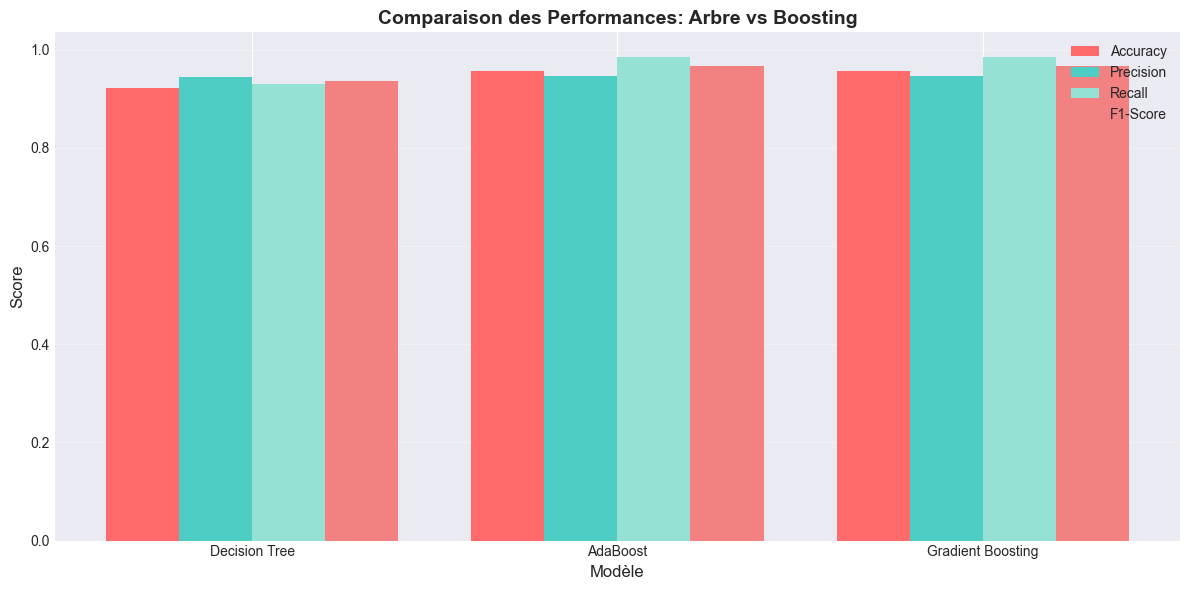


✅ Le Boosting améliore significativement les performances!


In [ ]:
# Comparaison: Arbre Simple vs Boosting
comparison_df = pd.DataFrame({
    'Modèle': ['Decision Tree', 'AdaBoost', 'Gradient Boosting'],
    'Accuracy': [accuracy_dt, accuracy_ada, accuracy_gb],
    'Precision': [precision_dt, precision_ada, precision_gb],
    'Recall': [recall_dt, recall_ada, recall_gb],
    'F1-Score': [f1_dt, f1_ada, f1_gb]
})

print("\n📊 COMPARAISON: Arbre Simple vs Boosting")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.2

ax.bar(x - 1.5*width, comparison_df['Accuracy'], width, label='Accuracy', color='#FF6B6B')
ax.bar(x - 0.5*width, comparison_df['Precision'], width, label='Precision', color='#4ECDC4')
ax.bar(x + 0.5*width, comparison_df['Recall'], width, label='Recall', color='#95E1D3')
ax.bar(x + 1.5*width, comparison_df['F1-Score'], width, label='F1-Score', color='#F38181')

ax.set_xlabel('Modèle', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des Performances: Arbre vs Boosting', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Modèle'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n✅ Le Boosting améliore significativement les performances!")

---

## Task 2.2: Support Vector Machines (SVM)

### 📚 Théorie des SVM

**Principe:**
- Trouver l'hyperplan optimal qui maximise la marge entre les classes
- **Support Vectors:** Points les plus proches de la frontière de décision
- **Marge:** Distance entre l'hyperplan et les support vectors les plus proches

**SVM Linéaire:**
- Pour données linéairement séparables
- Objectif: $\min_{w,b} \frac{1}{2}||w||^2$ sous contrainte $y_i(w^T x_i + b) \geq 1$

**Soft Margin SVM:**
- Pour données non linéairement séparables
- Introduit des variables de relâchement $\xi_i$
- Paramètre $C$: contrôle le compromis entre marge et erreurs
  - $C$ grand → Marge étroite, moins d'erreurs
  - $C$ petit → Marge large, plus d'erreurs tolérées

**Kernel SVM:**
- Pour données non-linéaires
- **Kernel Trick:** Projection implicite dans un espace de dimension supérieure
- Kernels courants:
  - Linéaire: $K(x, x') = x^T x'$
  - Polynomial: $K(x, x') = (\gamma x^T x' + r)^d$
  - RBF (Gaussian): $K(x, x') = \exp(-\gamma ||x - x'||^2)$

<style>
    .medical-section { font-family: 'Segoe UI', sans-serif; line-height: 1.6; }
    .grad-cobalt {
        background: linear-gradient(to right, #ffffff, #4facfe, #0006abff);
        -webkit-background-clip: text; background-clip: text;
        color: transparent; display: inline-block; font-weight: 800;
    }
    .size-xl { font-size: 2.2em; }
    .size-lg { font-size: 1.5em; margin-top: 20px; }
    .text-white { color: #ffffff; font-size: 1.1em; }
    .med-list { list-style: none; padding-left: 5px; color: #ffffff; }
    .med-list li { margin-bottom: 8px; padding-left: 15px; border-left: 3px solid #0006abff; }
    .highlight { color: #4facfe; font-weight: 600; }
</style>

<div class="medical-section">
    <h1 class="grad-cobalt size-xl">Tache 2.2 : Support Vector Machines (SVM)</h1>
    <h2 class="grad-cobalt size-lg">Théorie des SVM</h2>
    <p class="text-white">
        <strong>Principe :</strong> Trouver l'hyperplan optimal qui maximise la marge entre les classes.
    </p>
    <ul class="med-list">
        <li><span class="highlight">Support Vectors :</span> Points les plus proches de la frontière de décision.</li>
        <li><span class="highlight">Marge :</span> Distance entre l'hyperplan et les vecteurs supports les plus proches.</li>
    </ul>
    <h2 class="grad-cobalt size-lg">SVM Linéaire</h2>
    <p class="text-white">Objectif : Minimiser la norme du vecteur de poids sous contrainte de classification correcte :</p>
</div>

$$\boxed{\min_{w,b} \frac{1}{2}||w||^2 \quad \text{s.c.} \quad y_i(w^T x_i + b) \geq 1}$$

$$\boxed{K(x, x') = x^T x'}$$

<div class="medical-section">
    <h2 class="grad-cobalt size-lg">Soft Margin SVM</h2>
    <p class="text-white">
        Pour les données non linéairement séparables, on introduit des variables de relâchement (slack variables) et un paramètre C qui contrôle le compromis entre la largeur de la marge et les erreurs :
    </p>
    <ul class="med-list">
        <li><strong>C grand :</strong> Marge étroite, moins d'erreurs de classification tolérées.</li>
        <li><strong>C petit :</strong> Marge plus large, plus d'erreurs tolérées pour une meilleure généralisation.</li>
    </ul>
</div>

<div class="medical-section">
    <h2 class="grad-cobalt size-lg">Kernel SVM</h2>
    <p class="text-white">
        Le <span class="highlight">Kernel Trick</span> permet une projection implicite dans un espace de dimension supérieure pour traiter les données non linéaires. Voici les noyaux les plus courants :
    </p>
</div>

$$\boxed{K(x, x') = x^T x'}$$

$$\boxed{K(x, x') = (\gamma x^T x' + r)^d}$$

$$\boxed{K(x, x') = \exp(-\gamma ||x - x'||^2)}$$

In [7]:
from sklearn.svm import SVC

print("="*60)
print("🚀 ENTRAÎNEMENT: Support Vector Machines")
print("="*60)

# 1. SVM Linéaire
print("\n1. SVM Linéaire...")
svm_linear = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
svm_linear.fit(X_train_scaled, y_train)
y_pred_svm_linear = svm_linear.predict(X_test_scaled)
y_pred_proba_svm_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

accuracy_svm_linear = accuracy_score(y_test, y_pred_svm_linear)
f1_svm_linear = f1_score(y_test, y_pred_svm_linear)
precision_svm_linear = precision_score(y_test, y_pred_svm_linear)
recall_svm_linear = recall_score(y_test, y_pred_svm_linear)

print(f"   Accuracy:  {accuracy_svm_linear:.4f}")
print(f"   Precision: {precision_svm_linear:.4f}")
print(f"   Recall:    {recall_svm_linear:.4f}")
print(f"   F1-Score:  {f1_svm_linear:.4f}")
print(f"   Nombre de support vectors: {svm_linear.n_support_.sum()}")

print("\n💡 Concepts clés:")
print(f"   - Support Vectors: {svm_linear.n_support_} (par classe)")
print(f"   - Total: {svm_linear.n_support_.sum()} sur {len(y_train)} échantillons")
print("   - Marge: Distance maximale entre l'hyperplan et les support vectors")

🚀 ENTRAÎNEMENT: Support Vector Machines

1. SVM Linéaire...
   Accuracy:  0.9737
   Precision: 0.9859
   Recall:    0.9722
   F1-Score:  0.9790
   Nombre de support vectors: 32

💡 Concepts clés:
   - Support Vectors: [15 17] (par classe)
   - Total: 32 sur 455 échantillons
   - Marge: Distance maximale entre l'hyperplan et les support vectors


In [8]:
# 2. Soft Margin SVM avec différentes valeurs de C
print("\n" + "="*60)
print("2. Soft Margin SVM - Impact du paramètre C")
print("="*60)

c_values = [0.01, 0.1, 1.0, 10.0, 100.0]
svm_c_results = {}

for c in c_values:
    svm_c = SVC(kernel='linear', C=c, random_state=42)
    svm_c.fit(X_train_scaled, y_train)
    y_pred_c = svm_c.predict(X_test_scaled)
    
    accuracy_c = accuracy_score(y_test, y_pred_c)
    f1_c = f1_score(y_test, y_pred_c)
    
    svm_c_results[c] = {
        'model': svm_c,
        'accuracy': accuracy_c,
        'f1': f1_c,
        'n_support': svm_c.n_support_.sum()
    }
    
    print(f"C={c:6.2f} - Accuracy: {accuracy_c:.4f}, F1: {f1_c:.4f}, Support Vectors: {svm_c.n_support_.sum()}")

print("\n💡 Rôle du paramètre C:")
print("   - C petit: Marge large, plus de support vectors, plus de régularisation")
print("   - C grand: Marge étroite, moins de support vectors, moins d'erreurs tolérées")


2. Soft Margin SVM - Impact du paramètre C
C=  0.01 - Accuracy: 0.9649, F1: 0.9726, Support Vectors: 99
C=  0.10 - Accuracy: 0.9825, F1: 0.9861, Support Vectors: 51
C=  1.00 - Accuracy: 0.9737, F1: 0.9790, Support Vectors: 32
C= 10.00 - Accuracy: 0.9825, F1: 0.9861, Support Vectors: 26
C=100.00 - Accuracy: 0.9737, F1: 0.9793, Support Vectors: 26

💡 Rôle du paramètre C:
   - C petit: Marge large, plus de support vectors, plus de régularisation
   - C grand: Marge étroite, moins de support vectors, moins d'erreurs tolérées


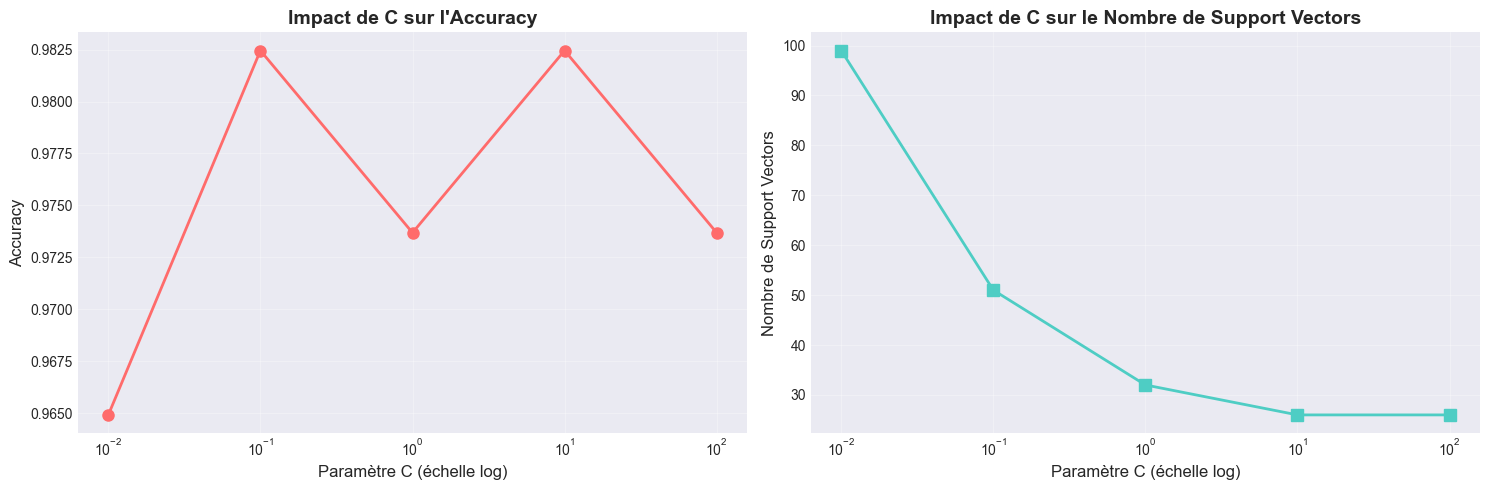

In [9]:
# Visualisation de l'impact de C
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

c_list = list(svm_c_results.keys())
accuracies_c = [svm_c_results[c]['accuracy'] for c in c_list]
n_support_c = [svm_c_results[c]['n_support'] for c in c_list]

# Accuracy vs C
axes[0].semilogx(c_list, accuracies_c, marker='o', linewidth=2, markersize=8, color='#FF6B6B')
axes[0].set_xlabel('Paramètre C (échelle log)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Impact de C sur l\'Accuracy', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Nombre de support vectors vs C
axes[1].semilogx(c_list, n_support_c, marker='s', linewidth=2, markersize=8, color='#4ECDC4')
axes[1].set_xlabel('Paramètre C (échelle log)', fontsize=12)
axes[1].set_ylabel('Nombre de Support Vectors', fontsize=12)
axes[1].set_title('Impact de C sur le Nombre de Support Vectors', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# 3. Kernel SVM (RBF)
print("\n" + "="*60)
print("3. Kernel SVM (RBF) - Cas Non-Linéaire")
print("="*60)

# Test de différents gamma pour le kernel RBF
gamma_values = [0.001, 0.01, 0.1, 1.0]
svm_rbf_results = {}

for gamma in gamma_values:
    svm_rbf = SVC(kernel='rbf', C=1.0, gamma=gamma, random_state=42, probability=True)
    svm_rbf.fit(X_train_scaled, y_train)
    y_pred_rbf = svm_rbf.predict(X_test_scaled)
    
    accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
    f1_rbf = f1_score(y_test, y_pred_rbf)
    
    svm_rbf_results[gamma] = {
        'model': svm_rbf,
        'accuracy': accuracy_rbf,
        'f1': f1_rbf,
        'predictions': y_pred_rbf
    }
    
    print(f"gamma={gamma:.3f} - Accuracy: {accuracy_rbf:.4f}, F1: {f1_rbf:.4f}")

# Meilleur gamma
best_gamma = max(svm_rbf_results.keys(), key=lambda g: svm_rbf_results[g]['f1'])
print(f"\n🏆 Meilleur gamma: {best_gamma} (F1-Score: {svm_rbf_results[best_gamma]['f1']:.4f})")

# Enregistrer le meilleur modèle RBF
svm_rbf_best = svm_rbf_results[best_gamma]['model']
y_pred_svm_rbf = svm_rbf_results[best_gamma]['predictions']
y_pred_proba_svm_rbf = svm_rbf_best.predict_proba(X_test_scaled)[:, 1]

print("\n💡 Explication du Kernel RBF:")
print("   - Formule: K(x, x') = exp(-gamma * ||x - x'||²)")
print("   - Projection implicite dans un espace de dimension infinie")
print("   - Permet de capturer des relations non-linéaires complexes")
print(f"   - gamma contrôle l'influence de chaque échantillon d'entraînement")


3. Kernel SVM (RBF) - Cas Non-Linéaire
gamma=0.001 - Accuracy: 0.9561, F1: 0.9664
gamma=0.010 - Accuracy: 0.9825, F1: 0.9861
gamma=0.100 - Accuracy: 0.9561, F1: 0.9645
gamma=1.000 - Accuracy: 0.6316, F1: 0.7742

🏆 Meilleur gamma: 0.01 (F1-Score: 0.9861)

💡 Explication du Kernel RBF:
   - Formule: K(x, x') = exp(-gamma * ||x - x'||²)
   - Projection implicite dans un espace de dimension infinie
   - Permet de capturer des relations non-linéaires complexes
   - gamma contrôle l'influence de chaque échantillon d'entraînement



📊 COMPARAISON: SVM Linéaire vs RBF
      Modèle  Accuracy  F1-Score  Support Vectors
SVM Linéaire  0.973684  0.979021               32
     SVM RBF  0.982456  0.986111               94


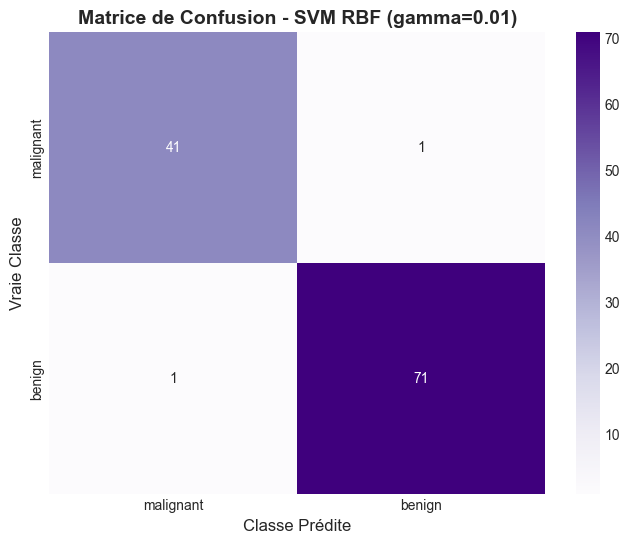

In [11]:
# Comparaison finale: SVM Linéaire vs RBF
print("\n" + "="*60)
print("📊 COMPARAISON: SVM Linéaire vs RBF")
print("="*60)

svm_comparison = pd.DataFrame({
    'Modèle': ['SVM Linéaire', 'SVM RBF'],
    'Accuracy': [accuracy_svm_linear, svm_rbf_results[best_gamma]['accuracy']],
    'F1-Score': [f1_svm_linear, svm_rbf_results[best_gamma]['f1']],
    'Support Vectors': [svm_linear.n_support_.sum(), svm_rbf_best.n_support_.sum()]
})

print(svm_comparison.to_string(index=False))
print("="*60)

# Matrice de confusion pour SVM RBF
cm_svm_rbf = confusion_matrix(y_test, y_pred_svm_rbf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_rbf, annot=True, fmt='d', cmap='Purples',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title(f'Matrice de Confusion - SVM RBF (gamma={best_gamma})', fontsize=14, fontweight='bold')
plt.ylabel('Vraie Classe', fontsize=12)
plt.xlabel('Classe Prédite', fontsize=12)
plt.show()

<style>
    .medical-section { font-family: 'Segoe UI', sans-serif; line-height: 1.6; }
    .grad-cobalt {
        background: linear-gradient(to right, #ffffff, #4facfe, #0006abff);
        -webkit-background-clip: text; background-clip: text;
        color: transparent; display: inline-block; font-weight: 800;
    }
    .size-xl { font-size: 2.2em; }
    .size-lg { font-size: 1.5em; margin-top: 20px; }
    .text-white { color: #ffffff; font-size: 1.1em; }
    .med-list { list-style: none; padding-left: 5px; color: #ffffff; }
    .med-list li { margin-bottom: 8px; padding-left: 15px; border-left: 3px solid #0006abff; }
    .highlight { color: #4facfe; font-weight: 600; }
</style>

<div class="medical-section">
    <h1 class="grad-cobalt size-xl">Tâche 2.3 : Visualisation des Frontières de Décision</h1>
    <p class="text-white">
        Pour visualiser les frontières de décision, nous devons réduire la dimensionnalité des données. Puisque notre dataset médical possède 30 caractéristiques, nous utilisons l'<strong>Analyse en Composantes Principales (PCA)</strong> pour projeter les données en 2 dimensions.
    </p>
    <h2 class="grad-cobalt size-lg">Analyse en Composantes Principales (PCA)</h2>
    <p class="text-white">
        L'objectif est de trouver les axes (vecteurs propres) qui maximisent la variance des données. La projection se base sur la décomposition de la matrice de covariance :
    </p>
</div>

$$\boxed{\Sigma = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(x_i - \bar{x})^T}$$

<div class="medical-section">
    <p class="text-white">
        Une fois les données projetées sur les deux premières composantes (PC1 et PC2), nous pouvons tracer les <strong>frontières de décision</strong> pour chaque modèle :
    </p>
    <ul class="med-list">
        <li><span class="highlight">Régression Logistique :</span> Produit une frontière de décision linéaire (un hyperplan).</li>
        <li><span class="highlight">SVM avec noyau RBF :</span> Capable de capturer des frontières non-linéaires complexes et circulaires.</li>
        <li><span class="highlight">Arbres de Décision :</span> Créent des frontières rectilignes perpendiculaires aux axes des caractéristiques.</li>
    </ul>
</div>

In [12]:
from sklearn.decomposition import PCA

print("🔍 Réduction de dimensionnalité avec PCA (2D)...")

# Réduction à 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Variance expliquée: {pca.explained_variance_ratio_.sum():.2%}")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.2%}")

# Entraîner les modèles sur les données 2D
print("\n🚀 Entraînement des modèles sur données 2D...")

# Régression Logistique
from sklearn.linear_model import LogisticRegression
logreg_2d = LogisticRegression(random_state=42)
logreg_2d.fit(X_train_pca, y_train)

# Arbre de Décision
dt_2d = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_2d.fit(X_train_pca, y_train)

# SVM RBF
svm_2d = SVC(kernel='rbf', C=1.0, gamma=0.1, random_state=42)
svm_2d.fit(X_train_pca, y_train)

print("✅ Modèles entraînés sur données 2D!")

🔍 Réduction de dimensionnalité avec PCA (2D)...
Variance expliquée: 63.36%
  - PC1: 44.41%
  - PC2: 18.94%

🚀 Entraînement des modèles sur données 2D...
✅ Modèles entraînés sur données 2D!


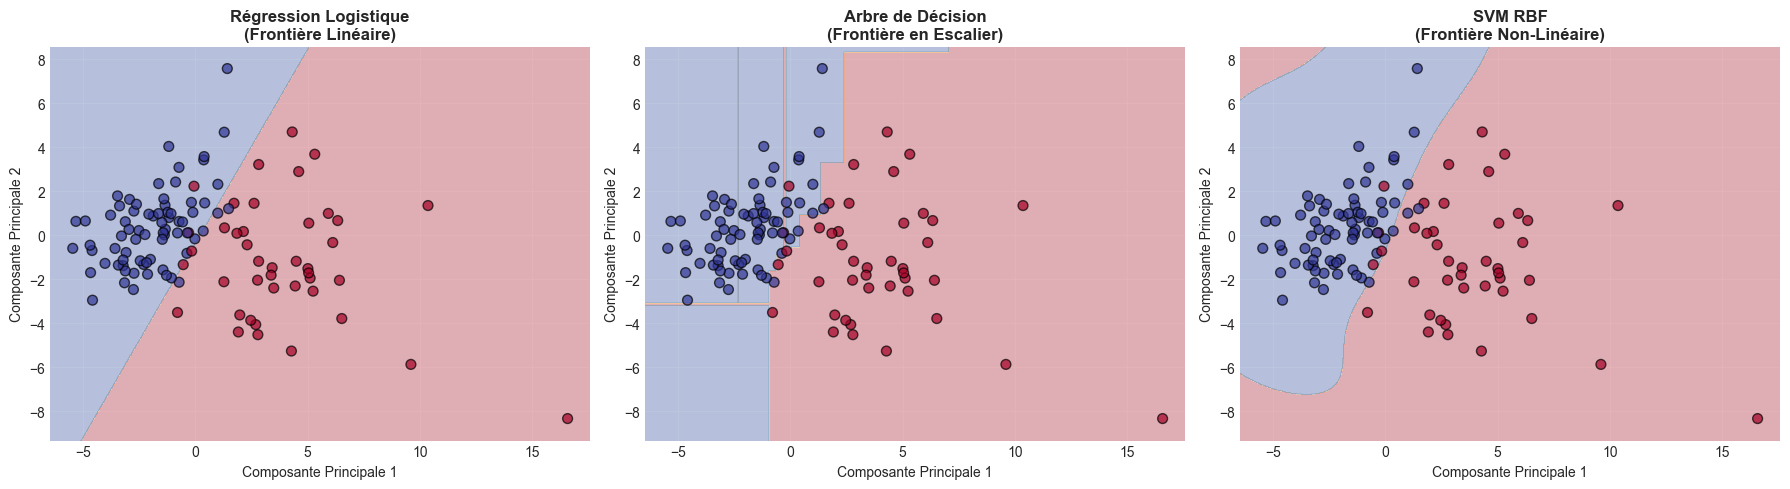


💡 Analyse des frontières de décision:
   - Régression Logistique: Frontière linéaire (droite)
   - Arbre de Décision: Frontière en escalier (divisions rectangulaires)
   - SVM RBF: Frontière non-linéaire lisse (courbe complexe)


In [13]:
# Fonction pour tracer les frontières de décision
def plot_decision_boundary(model, X, y, title, ax):
    """Trace la frontière de décision d'un modèle."""
    h = 0.02  # Pas de la grille
    
    # Créer une grille
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Prédire sur la grille
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Tracer la frontière
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='k', s=50, alpha=0.7)
    ax.set_xlabel('Composante Principale 1', fontsize=10)
    ax.set_ylabel('Composante Principale 2', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Visualisation des frontières
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(logreg_2d, X_test_pca, y_test, 
                       'Régression Logistique\n(Frontière Linéaire)', axes[0])
plot_decision_boundary(dt_2d, X_test_pca, y_test, 
                       'Arbre de Décision\n(Frontière en Escalier)', axes[1])
plot_decision_boundary(svm_2d, X_test_pca, y_test, 
                       'SVM RBF\n(Frontière Non-Linéaire)', axes[2])

plt.tight_layout()
plt.show()

print("\n💡 Analyse des frontières de décision:")
print("   - Régression Logistique: Frontière linéaire (droite)")
print("   - Arbre de Décision: Frontière en escalier (divisions rectangulaires)")
print("   - SVM RBF: Frontière non-linéaire lisse (courbe complexe)")

<span style="
    display: inline-block;
    background: linear-gradient(90deg,
        #ffffff,
        #87ceeb,
        #1e90ff,
        #0047ab);
    background-size: 300% 100%;
    -webkit-background-clip: text;
    background-clip: text;
    color: transparent;
    font-size: 48px;
    font-weight: 900;
    font-family: 'Montserrat', sans-serif;
    animation: skyFlow 4s ease-in-out infinite,
               skyFlicker 3s ease-in-out infinite;
    text-shadow: 0 0 10px rgba(30, 144, 255, 0.3),
                 0 0 20px rgba(135, 206, 235, 0.2);
    padding: 20px 40px;
    border: 3px solid transparent;
    border-image: linear-gradient(90deg, #ffffff, #87ceeb, #1e90ff) 1;
    border-radius: 10px;
    letter-spacing: 1px;
    line-height: 1.3;
    text-align: center;
    position: relative;
    overflow: hidden;
">Merci de nous avoir écouté pour cette seconde partie !</span>

<style>
@keyframes skyFlow {
    0% { 
        background-position: 0% 50%;
        border-image-source: linear-gradient(90deg, #ffffff, #87ceeb, #1e90ff);
    }
    25% { 
        background-position: 25% 50%;
        border-image-source: linear-gradient(90deg, #87ceeb, #1e90ff, #ffffff);
    }
    50% { 
        background-position: 100% 50%;
        border-image-source: linear-gradient(90deg, #1e90ff, #ffffff, #87ceeb);
    }
    75% { 
        background-position: 75% 50%;
        border-image-source: linear-gradient(90deg, #ffffff, #87ceeb, #1e90ff);
    }
    100% { 
        background-position: 0% 50%;
        border-image-source: linear-gradient(90deg, #ffffff, #87ceeb, #1e90ff);
    }
}

@keyframes skyFlicker {
    0%, 100% { 
        opacity: 1;
        filter: brightness(1) drop-shadow(0 0 5px rgba(30, 144, 255, 0.3));
        text-shadow: 0 0 10px rgba(30, 144, 255, 0.3),
                     0 0 20px rgba(135, 206, 235, 0.2);
    }
    50% { 
        opacity: 0.98;
        filter: brightness(1.15) drop-shadow(0 0 10px rgba(30, 144, 255, 0.5));
        text-shadow: 0 0 15px rgba(30, 144, 255, 0.5),
                     0 0 30px rgba(135, 206, 235, 0.3),
                     0 0 40px rgba(0, 71, 171, 0.2);
    }
}

/* Effet de nuages animés en arrière-plan */
span::before {
    content: '';
    position: absolute;
    top: 0;
    left: -100%;
    width: 100%;
    height: 100%;
    background: linear-gradient(90deg, 
        transparent, 
        rgba(255, 255, 255, 0.1), 
        transparent);
    animation: cloudMove 6s linear infinite;
    pointer-events: none;
    z-index: 1;
}

@keyframes cloudMove {
    0% { left: -100%; }
    100% { left: 100%; }
}

/* Étoiles scintillantes */
span::after {
    content: '';
    position: absolute;
    top: 20%;
    left: 10%;
    width: 3px;
    height: 3px;
    background: white;
    border-radius: 50%;
    box-shadow: 
        20px 30px 0 white,
        40px 10px 0 white,
        60px 40px 0 white,
        80px 20px 0 white,
        120px 30px 0 white;
    animation: twinkle 2s ease-in-out infinite;
    opacity: 0.5;
    pointer-events: none;
    z-index: 1;
}

@keyframes twinkle {
    0%, 100% { opacity: 0.3; transform: scale(1); }
    50% { opacity: 0.8; transform: scale(1.2); }
}

/* Import de la police Montserrat */
@import url('https://fonts.googleapis.com/css2?family=Montserrat:wght@900&display=swap');

/* Responsive */
@media (max-width: 768px) {
    span {
        font-size: 36px;
        padding: 15px 25px;
    }
}

@media (max-width: 480px) {
    span {
        font-size: 28px;
        padding: 12px 20px;
        line-height: 1.2;
    }
}
</style>